# Kernel Convergence Breakdown under Data-Dependent Standardization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hfallahgoul/HDL-JoE-replication/blob/main/02_Kernel_Convergence_Breakdown.ipynb)

This notebook evaluates the mean absolute kernel approximation error for Standard RFF versus KMZ Standardized RFF against the true Gaussian kernel as a function of the number of features $P \in [100, \dots, 12000]$. It replicates `kernel_approximation_error.pdf`.

In [ ]:
import os
import sys

CSV_NAME = 'PredictorData2021.csv'
GITHUB_RAW_URL = f'https://raw.githubusercontent.com/hfallahgoul/HDL-JoE-replication/main/{CSV_NAME}'
DRIVE_FALLBACK = f'/content/drive/MyDrive/HDL_Finance/{CSV_NAME}'

def get_data_path(csv_name=CSV_NAME):
    if os.path.exists(csv_name):
        return csv_name
    elif os.path.exists(DRIVE_FALLBACK):
        return DRIVE_FALLBACK
    else:
        try:
            import urllib.request
            print(f'Downloading {csv_name} from GitHub repository...')
            urllib.request.urlretrieve(GITHUB_RAW_URL, csv_name)
            if os.path.exists(csv_name):
                print(f'Download complete: {csv_name}')
                return csv_name
        except Exception as e:
            print(f'Note: Automatic download from GitHub failed ({e}).')
    return csv_name

csv_path = get_data_path()
print(f'Using dataset path: {csv_path}')


The file exists at: /content/drive/MyDrive/HDL_Finance/PredictorData2021.csv


Loading Goyal-Welch data ...
Data loaded: 1104 observations, 15 predictors.

Computing kernel approximation errors ...
  P =    100 ... std=0.0786  kmz=0.2247
  P =    200 ... std=0.0562  kmz=0.2069
  P =    500 ... std=0.0350  kmz=0.2015
  P =   1000 ... std=0.0250  kmz=0.1983
  P =   2000 ... std=0.0174  kmz=0.1985
  P =   5000 ... std=0.0111  kmz=0.1985
  P =  10000 ... std=0.0078  kmz=0.1977
  P =  12000 ... std=0.0070  kmz=0.1995

Figure saved to kernel_approximation_error.pdf


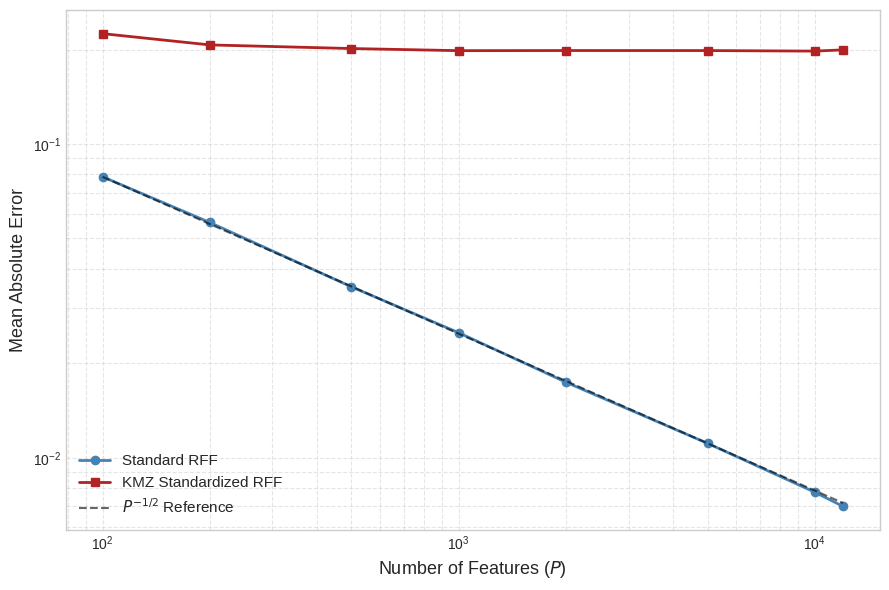

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

csv_path = get_data_path()


def load_and_prepare_goyal_welch_data(csv_path, start_date='1926-01-01', end_date='2020-12-31'):
    """
    Loads and prepares the Goyal-Welch predictor data, replicating the exact
    expanding-window standardization described in KMZ (2024), Section V.A.
    """
    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(df['yyyymm'], format='%Y%m')
    df = df.set_index('Date')

    cols_to_numeric = [
        'D12', 'E12', 'Index', 'BAA', 'AAA',
        'lty', 'tbl', 'corpr', 'ltr', 'CRSP_SPvw', 'Rfree'
    ]
    for col in cols_to_numeric:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df['dp']       = np.log(df['D12']) - np.log(df['Index'])
    df['dy']       = np.log(df['D12']) - np.log(df['Index'].shift(1))
    df['ep']       = np.log(df['E12']) - np.log(df['Index'])
    df['de']       = np.log(df['D12']) - np.log(df['E12'])
    df['dfy']      = df['BAA'] - df['AAA']
    df['tms']      = df['lty'] - df['tbl']
    df['dfr']      = df['corpr'] - df['ltr']
    df['exret']    = df['CRSP_SPvw'] - df['Rfree']
    df['lag_exret'] = df['exret'].shift(1)

    predictor_mnemonics = [
        'dfy', 'infl', 'svar', 'de', 'lty', 'tms', 'tbl', 'dfr',
        'dp', 'dy', 'ltr', 'ep', 'b/m', 'ntis', 'lag_exret'
    ]
    df_filtered = df.loc[start_date:end_date, predictor_mnemonics].copy()
    df_cleaned  = df_filtered.ffill()

    # Expanding-window standardization: at each t, divide by std over [0, t).
    # Requires min_obs = 36 months of history before the first usable observation.
    min_obs = 36
    df_standardized = pd.DataFrame(
        index=df_cleaned.index, columns=df_cleaned.columns, dtype=np.float64
    )
    for i in range(min_obs, len(df_cleaned)):
        expanding_std = df_cleaned.iloc[:i].std(ddof=1)
        expanding_std[expanding_std == 0] = 1.0          # guard against zero-std columns
        df_standardized.iloc[i] = df_cleaned.iloc[i] / expanding_std

    final_df = df_standardized.dropna().astype(np.float64)
    print(f"Data loaded: {final_df.shape[0]} observations, {final_df.shape[1]} predictors.")
    return final_df


def generate_rffs(G, P, gamma=2.0, seed=42):
    """
    Generates the KMZ sin/cos Random Fourier Feature pairs.

    For each draw omega_i ~ N(0, I_K), the feature pair is
        s_i(g) = [sin(gamma * omega_i' g), cos(gamma * omega_i' g)].
    Stacking P/2 such pairs yields a P-dimensional feature vector.

    The projection matrix Omega is drawn once with a fixed seed and held
    constant across all rolling windows, so that any cross-window variation
    in the standardized features is attributable solely to D_t, not to
    different projections.
    """
    if P % 2 != 0:
        raise ValueError("P must be even (sin/cos pairs).")

    np.random.seed(seed)
    K     = G.shape[1]
    omega = np.random.normal(size=(K, P // 2))          # shape (K, P/2)
    proj  = G.values @ omega                             # shape (T, P/2)

    rff_matrix = np.hstack([np.sin(gamma * proj), np.cos(gamma * proj)])
    return pd.DataFrame(
        rff_matrix, index=G.index,
        columns=[f'rff_{i+1}' for i in range(P)]
    )


def kmz_standardize_window(s_window, eps=1e-12):
    """
    Applies KMZ within-window standardization:
        tilde_s_i(g) = s_i(g) / sigma_hat_i

    where sigma_hat_i is the sample standard deviation (ddof=1, mean-centred)
    computed from the T training observations in s_window.

    Features with sigma_hat_i < eps are dropped (set to zero) to avoid
    numerical explosion when the within-window variance is negligible.

    Returns:
        s_tilde  : standardized feature matrix (T x P), numpy array
        valid    : boolean mask of length P indicating retained features
    """
    mu    = s_window.mean(axis=0)
    sigma = s_window.std(axis=0, ddof=1)

    valid  = sigma.values >= eps
    sigma_ = sigma.values.copy()
    sigma_[~valid] = 1.0                                # avoid division by zero

    s_tilde = (s_window.values - mu.values) / sigma_   # shape (T, P)
    s_tilde[:, ~valid] = 0.0

    return s_tilde, valid


def analyze_kernel_approximation_error(
    base_predictors,
    p_values,
    training_window_size,
    gamma=2.0,
    num_pairs=50,
    num_windows=200,
    rng_seed=0
):
    """
    Computes mean absolute kernel approximation error for standard RFF and
    KMZ standardized RFF as a function of P.

    For each P the experiment:
      1. Draws num_windows random 12-month rolling windows.
      2. Within each window, draws num_pairs random pairs (g_i, g_j).
      3. Computes:
           true kernel   : k_G(g_i, g_j) = exp(-gamma^2 ||g_i - g_j||^2 / 2)
           standard RFF  : (2/P) * s(g_i)' s(g_j)
           KMZ RFF       : (2/P) * tilde_s(g_i)' tilde_s(g_j)
      4. Reports mean |empirical - true| across all windows and pairs.

    Both empirical kernels use the same (2/P) normalization so that any
    difference in error is attributable to standardization, not scaling.
    """
    max_p    = max(p_values)
    rffs_all = generate_rffs(base_predictors, P=max_p, gamma=gamma)

    T   = training_window_size
    N   = len(base_predictors)
    rng = np.random.default_rng(rng_seed)

    # Pre-select window start indices (same for all P values)
    max_start      = N - T
    window_starts  = rng.choice(max_start, size=num_windows, replace=False)

    errors_standard = []
    errors_kmz      = []

    for p in p_values:
        print(f"  P = {p:>6d} ...", end=" ", flush=True)

        rffs = rffs_all.iloc[:, :p]           # first p features, fixed Omega

        err_std_total = 0.0
        err_kmz_total = 0.0
        n_valid_obs   = 0

        for w_start in window_starts:
            g_win = base_predictors.iloc[w_start : w_start + T]   # (T, K)
            s_win = rffs.iloc[w_start : w_start + T]               # (T, P)

            # --- KMZ within-window standardization (mean-centred, ddof=1) ---
            s_tilde, valid = kmz_standardize_window(s_win)

            # Pair indices
            pair_idx = rng.choice(T, size=(num_pairs, 2), replace=True)
            # Avoid identical pairs
            same = pair_idx[:, 0] == pair_idx[:, 1]
            pair_idx[same, 1] = (pair_idx[same, 1] + 1) % T

            for idx1, idx2 in pair_idx:
                g_i = g_win.iloc[idx1].values
                g_j = g_win.iloc[idx2].values

                # True Gaussian kernel
                k_true = np.exp(-gamma**2 * np.sum((g_i - g_j)**2) / 2.0)

                # --- Standard RFF kernel ---
                # s(g_i), s(g_j) are rows of the raw (unstandardized) feature matrix.
                # Normalization: (2/P) * s_i' s_j  [factor 2 from sin/cos pair construction]
                s_i = s_win.iloc[idx1].values
                s_j = s_win.iloc[idx2].values
                k_std = (2.0 / p) * (s_i @ s_j)

                # --- KMZ standardized RFF kernel ---
                # tilde_s(g_i) uses within-window scaling from D_t.
                # Same (2/P) normalization as standard RFF so the comparison
                # is apples-to-apples: any error difference reflects data-dependence,
                # not a scale mismatch.
                st_i = s_tilde[idx1]
                st_j = s_tilde[idx2]
                k_kmz = (2.0 / p) * (st_i @ st_j)

                err_std_total += abs(k_std  - k_true)
                err_kmz_total += abs(k_kmz - k_true)
                n_valid_obs   += 1

        mean_err_std = err_std_total / n_valid_obs
        mean_err_kmz = err_kmz_total / n_valid_obs
        errors_standard.append(mean_err_std)
        errors_kmz.append(mean_err_kmz)
        print(f"std={mean_err_std:.4f}  kmz={mean_err_kmz:.4f}")

    return p_values, errors_standard, errors_kmz


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
if __name__ == '__main__':

    GAMMA    = 2.0
    T_WINDOW = 12
    P_VALUES = [100, 200, 500, 1000, 2000, 5000, 10000, 12000]

    print("Loading Goyal-Welch data ...")
    data = load_and_prepare_goyal_welch_data(csv_path)

    print("\nComputing kernel approximation errors ...")
    p_res, err_std, err_kmz = analyze_kernel_approximation_error(
        base_predictors      = data,
        p_values             = P_VALUES,
        training_window_size = T_WINDOW,
        gamma                = GAMMA,
        num_pairs            = 50,
        num_windows          = 200,
        rng_seed             = 0
    )

    # -----------------------------------------------------------------------
    # Figure
    # -----------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.loglog(p_res, err_std,  'o-', color='steelblue', linewidth=2,
              label='Standard RFF')
    ax.loglog(p_res, err_kmz,  's-', color='firebrick', linewidth=2,
              label='KMZ Standardized RFF')

    # P^{-1/2} reference line anchored to the first standard RFF point
    ref_x = np.array(p_res, dtype=float)
    ref_y = err_std[0] * np.sqrt(p_res[0]) / np.sqrt(ref_x)
    ax.loglog(ref_x, ref_y, '--', color='black', alpha=0.6,
              label=r'$P^{-1/2}$ Reference')

    ax.set_xlabel('Number of Features ($P$)', fontsize=13)
    ax.set_ylabel('Mean Absolute Error', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()

    plt.savefig('kernel_approximation_error.pdf', format='pdf', bbox_inches='tight')
    print("\nFigure saved to kernel_approximation_error.pdf")
    plt.show()
